# Demo: 2D image RI2FL

> 2D RI2FL demo


In [ ]:
#| default_exp tutorial_2

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import aics_pipeline, manifest2csv

from monai.utils import set_determinism

set_determinism(0)

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
image_path = "../_data/aics"
# image_target_paths, data_manifest = aics_pipeline(6, image_path)

In [ ]:
# save data manifest as csv
# data_manifest.to_csv(image_path + 'aics_dataset.csv')

### Sorting & Preprocessing data

The downloaded images are very large, so we are going to extract only the channels we need for our model.

In [ ]:
# for each image, read channels to extract from data manifest and create the indices dict
indices_list =  []
# for X, y in zip(data_manifest["ChannelNumberBrightfield"].values, data_manifest["ChannelNumber405"].values):
#     indices_list.append({'C': [X, y], 'Z': range(12,60)})


In [ ]:
# extract substacks and save them in X and y folders
subdirs = ['../_data/aics/X', '../_data/aics/y']
# for filename, ind in zip(image_target_paths, indices_list):
#     extract_substacks(filename, output_dir=subdirs, indices=ind, split_dimension="C")

In [ ]:
patch_size = (16,64,64)
dir_patches = '../_data/aics/patches'
overlap = 0
# save_patches_grid(subdirs[0], subdirs[1], dir_patches, patch_size, overlap, squeeze_input=True)

In [ ]:
# save csv files containing train and test datasets
# X_paths = get_image_files(subdirs[0])
# y_paths = get_image_files(subdirs[1])

# manifest2csv(X_paths, y_paths, data_save_path=image_path+'/')

### Create Dataloader

In [ ]:
bs = 8

itemTfms = [RandRot90(prob=.5, spatial_axes=(1,2)), RandFlip(prob=0.75)] # RandCropND(patch_size)
batchTfms = [ScaleIntensity(min=0.0, max=1.0)]

data = BioDataLoaders.from_csv(
    dir_patches,                        # image_path
    csv_fname='train_patches.csv',      #'train.csv', 
    header='infer',
    pref='./',
    item_tfms=itemTfms,
    batch_tfms=batchTfms,
    img_cls=BioImageStack,
    target_img_cls=BioImageStack,
    show_summary=False,
    valid_pct=.25,
    bs=bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

train images: 1361 
validation images: 453


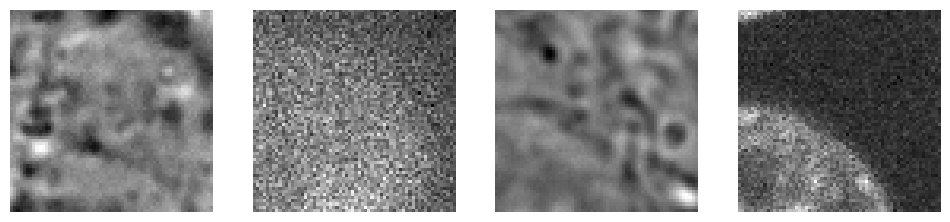

In [ ]:
data.show_batch(max_n=2, cmap='gray')

### Load and train a 2D model

In [ ]:
from bioMONAI.nets import UMamba



In [ ]:
# model = UNet(spatial_dims=3, in_channels=1, out_channels=1, channels=(32, 64, 128, 256),strides=(1, 2, 2), num_res_units=2)
model = UMamba(3,1,1,[3,3,3],[1,1,1],[1,1])

loss = MSELoss #MSSSIML1Loss(3, levels=2, window_size=8) 

metrics = [MSEMetric(), SSIMMetric(3), PSNRMetric(1)]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

epoch,train_loss,valid_loss,MSE,SSIM,PSNR,time
0,0.013875,0.010420,0.010420,0.389972,21.701559,00:32


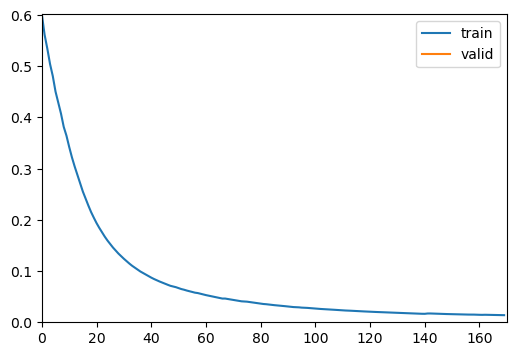

In [ ]:
trainer.fit_one_cycle(100)

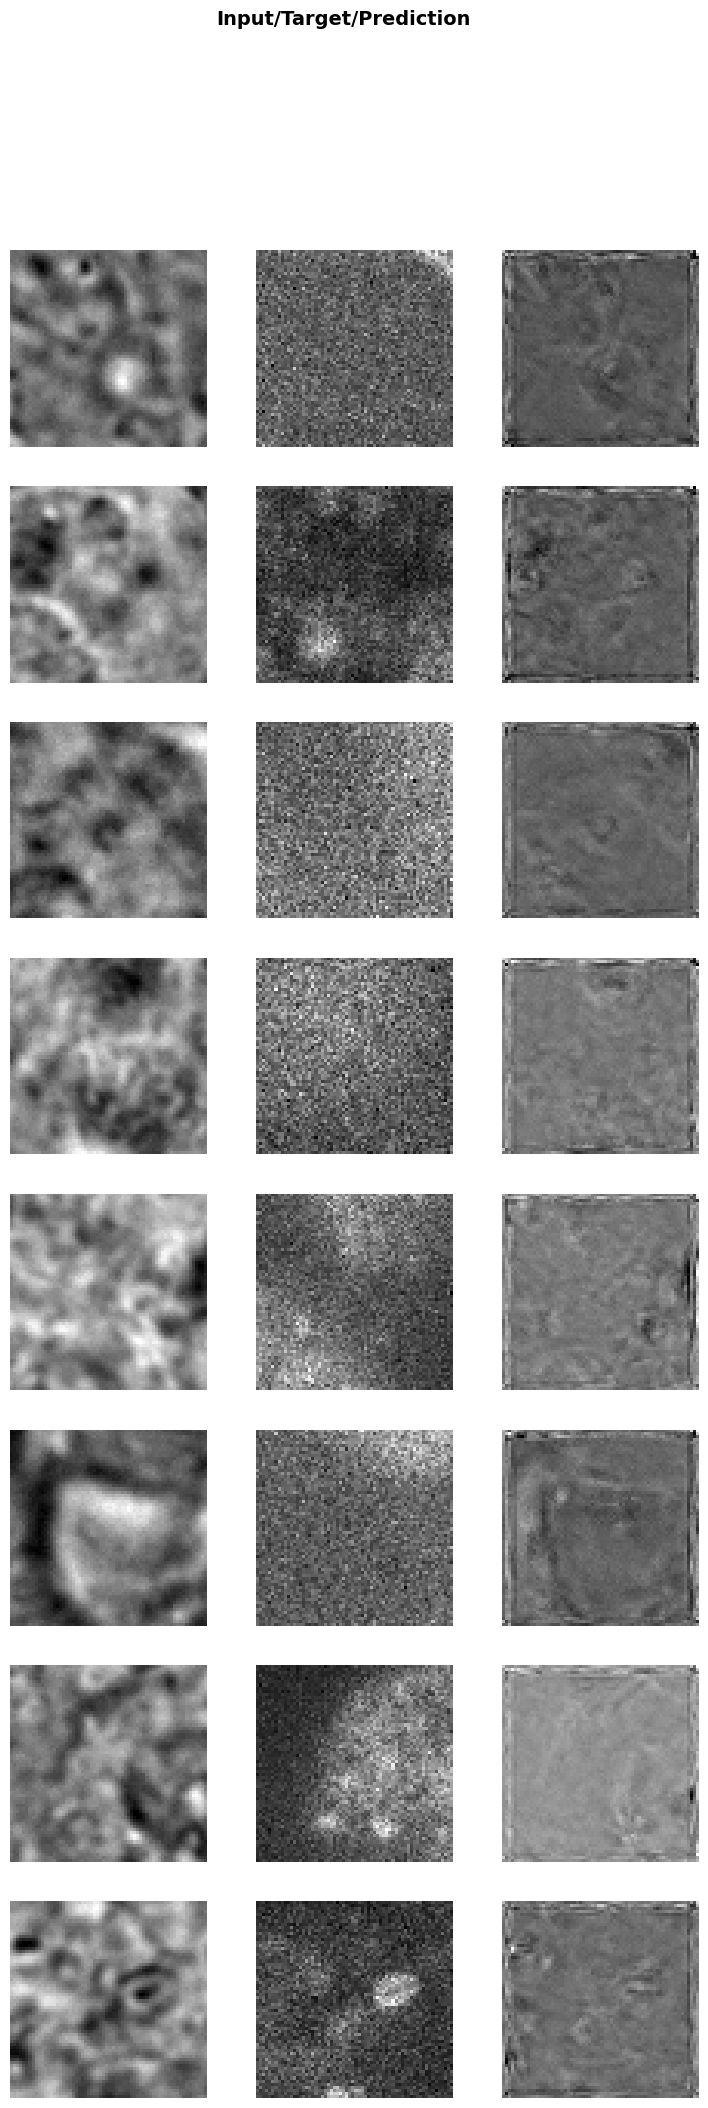

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!